In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

In [2]:
months = ['202505', '202506', '202507', '202508', '202509', '202510',
          '202511', '202512', '202601', '202602', '202603', '202604']

frames = []
for ym in months:
    path = f'/Users/jackhamilton/Downloads/Car ride/{ym}-capitalbikeshare-tripdata.csv'
    monthly = pd.read_csv(path, parse_dates=['started_at', 'ended_at'])
    assert set(monthly.columns) == set(frames[0].columns) if frames else True, f'Schema drift in {ym}'
    frames.append(monthly)

df = pd.concat(frames, ignore_index=True)

df = df.sort_values(by= 'started_at')
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
606766,863D4EC6A9906A59,classic_bike,2025-04-30 09:21:28.552,2025-05-01 10:21:23.120,Half & I St SW,31680.0,NaN,NaN,38.879262,-77.011016,NaN,NaN,casual
245519,8DD7207D439EA33D,classic_bike,2025-04-30 12:04:52.525,2025-05-01 09:18:58.397,4th St & Madison Dr NW,31288.0,Long Bridge Aquatic Center,31950.0,38.890496,-77.017246,38.870561,-77.044095,casual
513963,4F82E8F9EDABF91D,classic_bike,2025-04-30 12:37:25.218,2025-05-01 10:25:26.713,Jefferson Dr & 14th St SW,31247.0,Henry Bacon Dr & Lincoln Memorial Circle NW,31289.0,38.888553,-77.032427,38.890539,-77.049383,casual
632761,DAE0FCAA557FCD9B,classic_bike,2025-04-30 13:34:34.776,2025-05-01 14:34:31.761,Long Bridge Park / Long Bridge Dr & 6th St S,31090.0,NaN,NaN,38.865553,-77.050030,NaN,NaN,member
632756,4DC1A5EF9097B419,classic_bike,2025-04-30 14:58:07.449,2025-05-01 15:58:03.082,Anacostia Park,31820.0,NaN,NaN,38.873308,-76.983363,NaN,NaN,casual


In [3]:
df.shape

(6320579, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6320579 entries, 606766 to 6101030
Data columns (total 13 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             object        
 1   rideable_type       object        
 2   started_at          datetime64[ns]
 3   ended_at            datetime64[ns]
 4   start_station_name  object        
 5   start_station_id    float64       
 6   end_station_name    object        
 7   end_station_id      float64       
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       object        
dtypes: datetime64[ns](2), float64(6), object(5)
memory usage: 675.1+ MB


# Cleaning

In [5]:
df['duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

def classify(d):
    if d < 0: return 'negative'
    if d < 1: return 'sub_minute'
    if d > 1440: return 'over_24h'    
    return 'valid'

df['qa_flag'] = df['duration_min'].apply(classify)

print(df.groupby(['qa_flag', 'member_casual']).size().unstack())
print(df.groupby(['qa_flag', 'rideable_type']).size().unstack())

member_casual   casual   member
qa_flag                        
negative            18       17
over_24h          3393     1281
sub_minute       53188    89558
valid          1760435  4412689
rideable_type  classic_bike  electric_bike
qa_flag                                   
negative               16.0           19.0
over_24h             4674.0            NaN
sub_minute              NaN       142746.0
valid             2193355.0      3979769.0


In [6]:
#percent of valid data
print(100*(6173124/6320579))

#percent under 1 minute
print(100*(142746/6320579))

#percent over 24 hours
print(100*(4674/6320579))


print(100*(1273/4412689))
print(100*(4652/2193355))

97.66706499515313
2.258432336657765
0.07394892145165814
0.028848622687889406
0.212095169272644


In [7]:
df = df[(df['duration_min'] > 1) & (df['duration_min'] < 1440)]

In [8]:
df['ride_id'].duplicated().sum()

np.int64(0)

In [9]:
df['is_dockless_start'] = df['start_station_name'].isna()
df['is_dockless_end'] = df['end_station_name'].isna()
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,duration_min,qa_flag,is_dockless_start,is_dockless_end
245519,8DD7207D439EA33D,classic_bike,2025-04-30 12:04:52.525,2025-05-01 09:18:58.397,4th St & Madison Dr NW,31288.0,Long Bridge Aquatic Center,31950.0,38.890496,-77.017246,38.870561,-77.044095,casual,1274.097867,valid,False,False
513963,4F82E8F9EDABF91D,classic_bike,2025-04-30 12:37:25.218,2025-05-01 10:25:26.713,Jefferson Dr & 14th St SW,31247.0,Henry Bacon Dr & Lincoln Memorial Circle NW,31289.0,38.888553,-77.032427,38.890539,-77.049383,casual,1308.024917,valid,False,False
487968,921C3E610E49F43D,classic_bike,2025-04-30 15:01:14.209,2025-05-01 11:05:19.700,13th St & New York Ave NW,31227.0,13th St & New York Ave NW,31227.0,38.900283,-77.029822,38.900283,-77.029822,member,1204.091517,valid,False,False
316657,A6B316C515308972,classic_bike,2025-04-30 17:36:14.790,2025-05-01 06:42:47.646,8th & Eye St SE / Barracks Row,31608.0,1st & M St SE,31650.0,38.879200,-76.995300,38.876893,-77.006072,member,786.547600,valid,False,False
319966,E9231D6F421D1859,classic_bike,2025-04-30 19:04:11.379,2025-05-01 07:02:54.138,Capitol Heights Metro,32419.0,Capitol Heights Metro,32419.0,38.888524,-76.913188,38.888524,-76.913188,casual,718.712650,valid,False,False


In [10]:
df['is_dockless_start'].value_counts()

is_dockless_start
False    5047379
True     1125745
Name: count, dtype: int64

In [11]:
df['is_dockless_end'].value_counts()

is_dockless_end
False    5024401
True     1148723
Name: count, dtype: int64

In [12]:
#Percent that is dockless for start
print(100*(1212059/6320579))

#Percent that is dockless for start
print(100*(1261050/6320579))

19.176391909665238
19.951494950067076


In [13]:
#Adds hour feature to df (based on start_time)

#df['started_at'].dtype
df['hour'] = df['started_at'].dt.hour

In [14]:
#Adds day of week feature to df

df['dow'] = df['started_at'].dt.day_of_week

In [15]:
# Is weekend is a boolean value to identify if it's the weekend or not

df['is_weekend'] = df['dow'] >= 5 

In [16]:
# Adds a month feature to df

df['month'] = df['started_at'].dt.month

In [17]:
# Adds a season column to df

def season(mon):
    if mon in [12,1,2]:
        return 'Winter'
    elif mon in [3,4,5]:
        return 'Spring'
    elif mon in [6,7,8]:
        return 'Summer'
    elif mon in [9,10,11]:
        return 'Fall'
    
df['season'] = df['month'].apply(season)

In [18]:
#Groups the time of day into describable categories

def time_of_day(time):
    if time in [4,5,6]:
        return 'Early Morning'
    elif time in [7,8,9]:
        return 'Morning Rush'
    elif (time > 9 & time < 16):
        return 'Mid day'
    elif time in [16,17,18,19]:
        return 'Evening Rush'
    elif time in [20,21,22]:
        return 'evening'
    else:
        return 'Late Night'


df['time_of_day'] = df['hour'].apply(time_of_day)

In [19]:
# Adds a is_rush_hour column to df (if time is 7am-9am or 4pm-7pm)

df['is_rush_hour'] = (df['time_of_day'] == 'Morning Rush') | (df['time_of_day'] == 'Evening Rush')

In [20]:
# Adds a distance colume for how far the rider travelled (This is Birds eye view, not street distance traveled)

def haversine_vec(lat1, lng1, lat2, lng2):
    R = 6371
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine_vec(df['start_lat'], df['start_lng'],
                                   df['end_lat'],   df['end_lng'])

In [21]:
# Adds a round_trip column to see if the rider ended their ride exactly where they started

df['round_trip'] = (df['start_station_id'] == df['end_station_id']) & df['start_station_id'].notna()

In [22]:
#Adds a speed column (distance over time)
df['speed (km/h)'] = df['distance_km'] / (df['duration_min'] /60)

In [23]:
#Boolean version of ridetype (is the bike electric or is it classic)

df['is_electric'] = (df['rideable_type'] == 'electric_bike')

In [24]:
# station_total_rides: Lists the total count of the start station for each designated row
#station_pct_casual: fraction of the start station that is casual
#station_avg_duration: duration of each ride starting at that station_station
#station_weekday_share: fraction of rides from this station on weekday
#station_rush_hour_share: fraction of the rides from this station during rush hour


station_stats = df.groupby('start_station_id').agg(
    station_total_rides=('ride_id','count'),
    station_pct_casual=('member_casual', lambda s: (s == 'casual').mean()),
    station_avg_duration=('duration_min','mean'),
    station_weekday_share=('is_weekend', lambda s: (~s).mean()),
    station_rush_hour_share=('is_rush_hour','mean'),
    avg_lat=('start_lat','mean'),
    avg_lng=('start_lng','mean'),
    map_station_name=('start_station_name','first'),
).reset_index()

df = df.merge(station_stats, on= 'start_station_id', how= 'left')

# EDA

In [25]:
df.describe()

,started_at,ended_at,start_station_id,end_station_id,start_lat,start_lng,end_lat,end_lng,duration_min,hour,...,month,distance_km,speed (km/h),station_total_rides,station_pct_casual,station_avg_duration,station_weekday_share,station_rush_hour_share,avg_lat,avg_lng
count,6173124,6173124,5.047379e+06,5.022524e+06,6.173124e+06,6.173124e+06,6.173043e+06,6.173043e+06,6.173124e+06,6.173124e+06,...,6.173124e+06,6.173043e+06,6.173043e+06,5.047379e+06,5.047379e+06,5.047379e+06,5.047379e+06,5.047379e+06,5.047379e+06,5.047379e+06
mean,2025-10-09 09:31:50.007248640,2025-10-09 09:45:54.532070144,3.140614e+04,3.140751e+04,3.890635e+01,-7.703277e+01,3.890575e+01,-7.703259e+01,1.407541e+01,1.427113e+01,...,6.749352e+00,1.950567e+00,1.089074e+01,1.666513e+04,2.999482e-01,1.423844e+01,7.144005e-01,1.541828e-01,3.890511e+01,-7.703263e+01
min,2025-04-30 12:04:52.525000,2025-05-01 00:00:02.563000,3.020000e+04,3.020000e+04,3.876000e+01,-7.743000e+01,3.866000e+01,-7.772000e+01,1.000017e+00,0.000000e+00,...,1.000000e+00,0.000000e+00,0.000000e+00,9.000000e+00,1.000000e-01,7.907094e+00,3.000000e-01,0.000000e+00,3.876684e+01,-7.741936e+01
25%,2025-07-10 15:32:52.258999808,2025-07-10 15:48:48.348999936,3.120900e+04,3.121200e+04,3.889344e+01,-7.704506e+01,3.889303e+01,-7.704506e+01,5.539729e+00,1.100000e+01,...,4.000000e+00,9.003047e-01,7.825142e+00,8.390000e+03,2.398667e-01,1.119784e+01,6.816811e-01,1.091923e-01,3.889385e+01,-7.704498e+01
50%,2025-09-21 16:05:07.853999872,2025-09-21 16:20:38.984500224,3.129600e+04,3.129500e+04,3.890569e+01,-7.703000e+01,3.890551e+01,-7.703000e+01,9.336850e+00,1.500000e+01,...,7.000000e+00,1.549635e+00,1.098497e+01,1.479100e+04,2.637059e-01,1.262421e+01,7.068798e-01,1.538212e-01,3.890531e+01,-7.703187e+01
75%,2026-01-03 22:56:37.962750208,2026-01-03 23:05:25.074249984,3.161500e+04,3.161600e+04,3.892000e+01,-7.701162e+01,3.891902e+01,-7.701162e+01,1.574262e+01,1.800000e+01,...,9.000000e+00,2.589185e+00,1.420436e+01,2.184300e+04,3.048104e-01,1.493497e+01,7.440637e-01,1.889065e-01,3.891774e+01,-7.701237e+01
max,2026-04-30 23:59:54.637000,2026-05-01 17:59:23.585000,3.320700e+04,3.320700e+04,3.913000e+01,-7.681000e+01,3.919000e+01,-7.648000e+01,1.439945e+03,2.300000e+01,...,1.200000e+01,4.719880e+01,2.320262e+02,5.659000e+04,9.369369e-01,6.044607e+01,1.000000e+00,5.127202e-01,3.912583e+01,-7.682554e+01
std,NaN,NaN,3.351803e+02,3.371345e+02,2.921392e-02,3.707054e-02,2.924565e-02,3.708657e-02,2.605776e+01,4.969801e+00,...,2.952434e+00,1.568502e+00,5.343874e+00,1.141332e+04,1.113504e-01,4.956091e+00,6.134889e-02,6.153627e-02,2.662364e-02,3.548519e-02


In [26]:
df['rideable_type'].value_counts()   

rideable_type
electric_bike    3979769
classic_bike     2193355
Name: count, dtype: int64

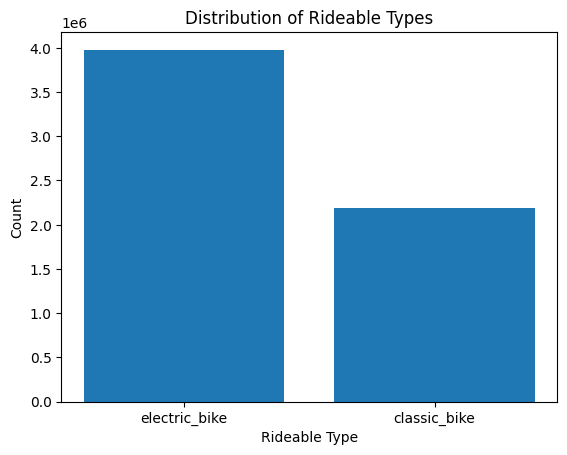

In [27]:
rideable_type_counts = df['rideable_type'].value_counts()
plt.bar(rideable_type_counts.index, rideable_type_counts.values)
plt.title('Distribution of Rideable Types')
plt.xlabel('Rideable Type')
plt.ylabel('Count')
plt.show()

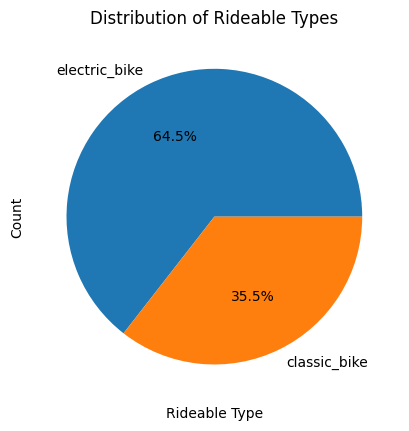

In [28]:
plt.pie(rideable_type_counts.values, labels = rideable_type_counts.index, autopct='%1.1f%%') 
plt.title('Distribution of Rideable Types')
plt.xlabel('Rideable Type')
plt.ylabel('Count')
plt.show()

In [29]:
df['member_casual'].value_counts()

member_casual
member    4412689
casual    1760435
Name: count, dtype: int64

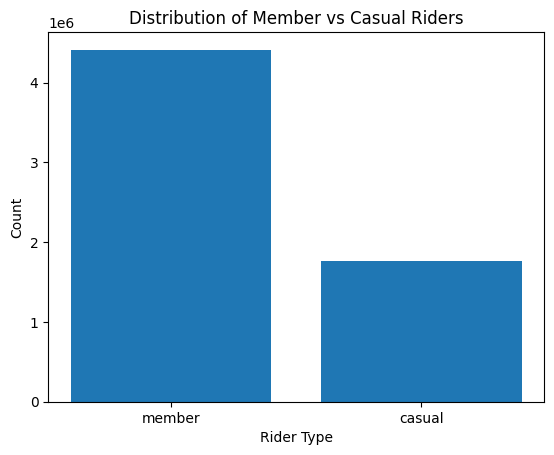

In [30]:
member_casual_counts = df['member_casual'].value_counts()
plt.bar(member_casual_counts.index, member_casual_counts.values)
plt.title('Distribution of Member vs Casual Riders')
plt.xlabel('Rider Type')
plt.ylabel('Count')
plt.show()

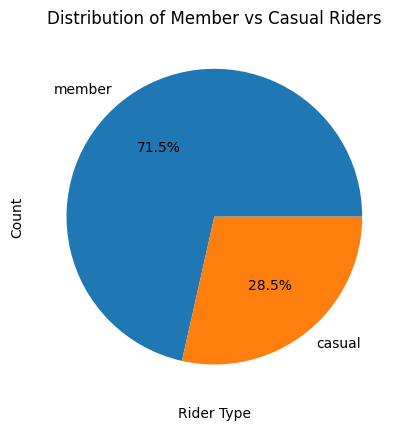

In [31]:
plt.pie(member_casual_counts.values, labels=member_casual_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Member vs Casual Riders')
plt.xlabel('Rider Type')
plt.ylabel('Count')
plt.show()

In [32]:
popular_start = df[df['start_station_id'] == 31623.0]
popular_start

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,speed (km/h),is_electric,station_total_rides,station_pct_casual,station_avg_duration,station_weekday_share,station_rush_hour_share,avg_lat,avg_lng,map_station_name
308,1D848FF825B5BDBE,classic_bike,2025-05-01 00:54:11.005,2025-05-01 01:01:53.709,Columbus Circle / Union Station,31623.0,13th & D St NE,31622.0,38.896960,-77.004930,...,11.791109,False,56590.0,0.236597,11.019951,0.804082,0.18141,38.89697,-77.00493,Columbus Circle / Union Station
744,0C31DB573A613469,electric_bike,2025-05-01 05:58:51.543,2025-05-01 06:04:54.153,Columbus Circle / Union Station,31623.0,Smithsonian-National Mall / Jefferson Dr & 12t...,31248.0,38.896960,-77.004930,...,22.329021,True,56590.0,0.236597,11.019951,0.804082,0.18141,38.89697,-77.00493,Columbus Circle / Union Station
808,15806883E0C1DBE1,classic_bike,2025-05-01 06:11:09.308,2025-05-01 06:21:01.007,Columbus Circle / Union Station,31623.0,M St & New Jersey Ave SE,31208.0,38.896960,-77.004930,...,14.037460,False,56590.0,0.236597,11.019951,0.804082,0.18141,38.89697,-77.00493,Columbus Circle / Union Station
814,263F4E577F725B23,electric_bike,2025-05-01 06:11:51.044,2025-05-01 06:35:46.288,Columbus Circle / Union Station,31623.0,Clark St & 26th St S,31012.0,38.896960,-77.004930,...,16.398146,True,56590.0,0.236597,11.019951,0.804082,0.18141,38.89697,-77.00493,Columbus Circle / Union Station
817,DD02CCB4155AB881,classic_bike,2025-05-01 06:12:02.602,2025-05-01 06:19:58.649,Columbus Circle / Union Station,31623.0,4th & M St SE,31652.0,38.896960,-77.004930,...,17.213781,False,56590.0,0.236597,11.019951,0.804082,0.18141,38.89697,-77.00493,Columbus Circle / Union Station
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6172880,B5B52C0BA0C99000,classic_bike,2026-04-30 23:16:08.667,2026-04-30 23:20:26.313,Columbus Circle / Union Station,31623.0,Massachusetts Ave & 6th St NE,31657.0,38.896960,-77.004930,...,10.118580,False,56590.0,0.236597,11.019951,0.804082,0.18141,38.89697,-77.00493,Columbus Circle / Union Station
6172940,083F8C402A0410E5,classic_bike,2026-04-30 23:25:36.611,2026-04-30 23:30:18.612,Columbus Circle / Union Station,31623.0,Maryland Ave & E St NE,31640.0,38.896960,-77.004930,...,13.457158,False,56590.0,0.236597,11.019951,0.804082,0.18141,38.89697,-77.00493,Columbus Circle / Union Station
6172975,727BB6A354D60B88,electric_bike,2026-04-30 23:31:05.826,2026-04-30 23:35:43.250,Columbus Circle / Union Station,31623.0,10th & H St NE,31672.0,38.896960,-77.004930,...,14.383655,True,56590.0,0.236597,11.019951,0.804082,0.18141,38.89697,-77.00493,Columbus Circle / Union Station
6173025,E5C43F2F395BE6E6,electric_bike,2026-04-30 23:38:25.919,2026-04-30 23:57:42.457,Columbus Circle / Union Station,31623.0,36th & Calvert St NW / Glover Park,31304.0,38.896960,-77.004930,...,19.721453,True,56590.0,0.236597,11.019951,0.804082,0.18141,38.89697,-77.00493,Columbus Circle / Union Station


In [33]:
#Number of rides
print(f"Total rides: {len(df):,}")
print(f"Period: {df['started_at'].min().date()} to {df['started_at'].max().date()}")

Total rides: 6,173,124
Period: 2025-04-30 to 2026-04-30


In [34]:
df.groupby('start_station_name')['ride_id'].count().reset_index().sort_values(by='ride_id', ascending = False)

,start_station_name,ride_id
336,Columbus Circle / Union Station,56590
604,New Hampshire Ave & T St NW,50532
71,15th & P St NW,43838
215,5th & K St NW,43080
382,Eastern Market Metro,42996
...,...,...
656,Potomac Greens & Carpenter Rd,10
735,South Dakota Ave & Ingraham St NE,9
594,NcNair Farms Dr & Thomas Jefferson Dr,8
63,15 & Chapin St NW,6


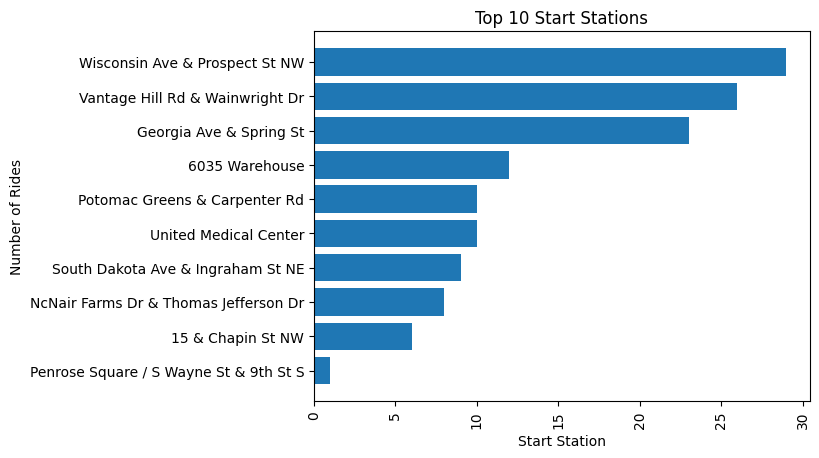

In [35]:
top_start_stations = df.groupby('start_station_name')['ride_id'].count().reset_index().sort_values(by='ride_id').head(10)
plt.barh(top_start_stations['start_station_name'], top_start_stations['ride_id'])
plt.title('Top 10 Start Stations')
plt.xlabel('Start Station')
plt.ylabel('Number of Rides')
plt.xticks(rotation=90)
plt.show()

In [36]:
df.groupby('end_station_name')['ride_id'].count().reset_index().sort_values(by='ride_id', ascending = False)

,end_station_name,ride_id
336,Columbus Circle / Union Station,56975
604,New Hampshire Ave & T St NW,51136
71,15th & P St NW,44380
215,5th & K St NW,43604
382,Eastern Market Metro,43053
...,...,...
594,NcNair Farms Dr & Thomas Jefferson Dr,10
769,United Medical Center,9
219,6035 Warehouse,6
63,15 & Chapin St NW,3


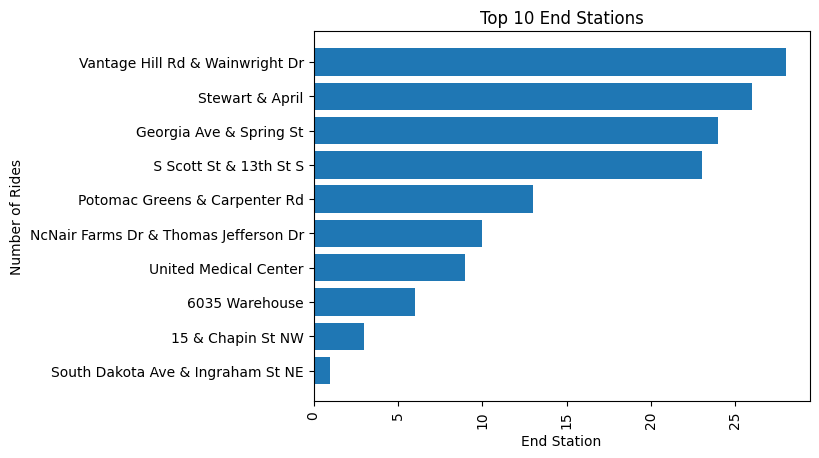

In [37]:
top_end_stations = df.groupby('end_station_name')['ride_id'].count().reset_index().sort_values(by='ride_id').head(10)
plt.barh(top_end_stations['end_station_name'], top_end_stations['ride_id'])
plt.title('Top 10 End Stations')
plt.xlabel('End Station')
plt.ylabel('Number of Rides')
plt.xticks(rotation=90)
plt.show()

In [38]:
df['member_casual'].value_counts()

member_casual
member    4412689
casual    1760435
Name: count, dtype: int64

# date time

In [39]:
time_average = round(df['duration_min'].mean(),2)
time_median = round(df['duration_min'].median(), 2)

print(f'The average time of a ride is: {time_average} minutes')
print(f'The median time of a ride is: {time_median} minutes')

The average time of a ride is: 14.08 minutes
The median time of a ride is: 9.34 minutes


In [40]:
time_max = round(df['duration_min'].max(), 2)
time_min = round(df['duration_min'].min(),2)

print(f'The shortest ride was {time_min} minutes long')
print(f'The longest ride was {time_max} minutes long')


The shortest ride was 1.0 minutes long
The longest ride was 1439.95 minutes long


In [41]:
df.groupby('member_casual')['duration_min'].mean().reset_index()

,member_casual,duration_min
0,casual,19.616222
1,member,11.864917


In [42]:
df.groupby('rideable_type')['duration_min'].mean().reset_index()

,rideable_type,duration_min
0,classic_bike,17.049611
1,electric_bike,12.436256


In [43]:
#Casual riders have a longer average ride time than members. This could be because casual riders are less familiar with the bike-sharing system and may take longer routes or spend more time exploring the area, while members may use the bikes for more direct and efficient transportation. Additionally, casual riders may be more likely to use the bikes for leisure activities, which could result in longer ride times compared to members who may use the bikes primarily for commuting or short trips.
df[df['member_casual'] == 'casual'].groupby('rideable_type')['duration_min'].mean().reset_index()

,rideable_type,duration_min
0,classic_bike,27.305739
1,electric_bike,14.767943


In [44]:
#Members have a shorter average ride time than casual riders. This could be because members are more familiar with the bike-sharing system and may use it for shorter, more frequent trips, while casual riders might use it for longer, less frequent trips. Additionally, members may have access to discounts or incentives that encourage them to take shorter rides, while casual riders may be more likely to take longer rides without such incentives.
df[df['member_casual'] == 'member'].groupby('rideable_type')['duration_min'].mean().reset_index()

,rideable_type,duration_min
0,classic_bike,12.433846
1,electric_bike,11.568179


In [45]:
new_df = df[(df['duration_min'] < 60) & (df['duration_min'] > 1 )]

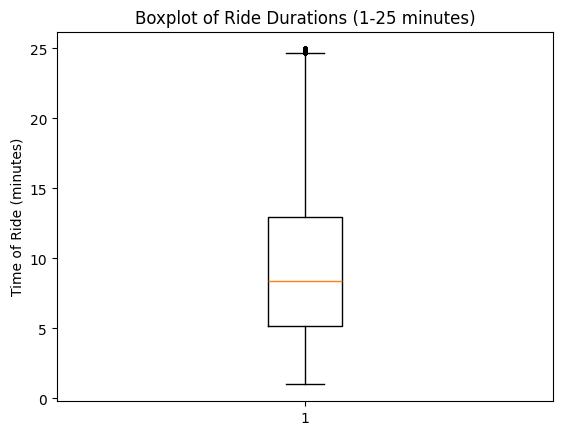

In [46]:
new_df2 = df[(df['duration_min'] < 25) & (df['duration_min'] > 1 )]
plt.boxplot(new_df2['duration_min'], flierprops=dict(markersize=2), showfliers=True)
plt.title('Boxplot of Ride Durations (1-25 minutes)')
plt.ylabel('Time of Ride (minutes)')
plt.show()

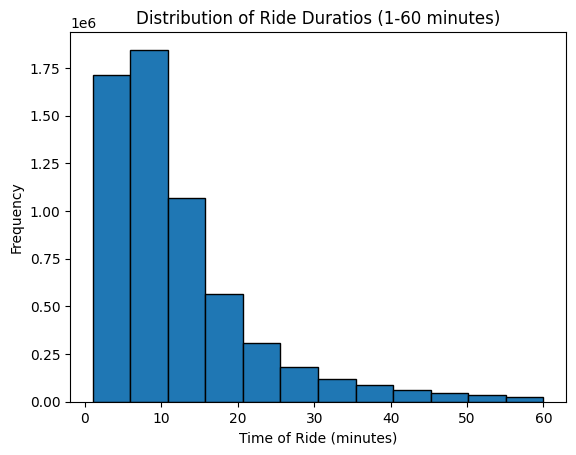

In [47]:

plt.hist(new_df['duration_min'], bins=12, edgecolor='black')
plt.title('Distribution of Ride Duratios (1-60 minutes)')
plt.xlabel('Time of Ride (minutes)')
plt.ylabel('Frequency')
plt.show()